# Examples of Real Data Analysis using MultiCMH

In [1]:
## set working directory to the root
import os
root_marker = 'setup.py'
current_dir = os.getcwd()
if not os.path.exists(os.path.join(current_dir, root_marker)):
    parent_dir = os.path.dirname(current_dir)
    os.chdir(parent_dir)
    # print(f"Working directory changed to: {os.getcwd()}")
# else:
    # print(f"Already at the root directory: {os.getcwd()}")
    
from multiCMH import *
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

def drop_columns(df, id_cols=None, max_categories=8, na_threshold=0.10):
    df = df.copy()
    if id_cols:
        df.drop(columns=id_cols, inplace=True, errors='ignore')
    high_card_cols = [
        col for col in df.select_dtypes(include=['object', 'category']).columns
        if df[col].nunique(dropna=True) > max_categories
    ]
    print(f'dropping high-cardinality nominal columns {high_card_cols}')
    df.drop(columns=high_card_cols, inplace=True)
    # 3. Drop columns with high missingness
    na_cols = df.columns[df.isna().mean() > na_threshold].tolist()
    print(f'dropping high NA proportion columns {na_cols}')
    df.drop(columns=na_cols, inplace=True)
    return df

def encode_ordinal_column(df, column_name, category_order):
    # df = df.copy()  # Avoid modifying original DataFrame
    cat = pd.Categorical(df[column_name], categories=category_order, ordered=True)
    df[column_name] = cat.codes
    # return df

# California Housing Data
https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html

We use California Housing Data instead of the private data for publicly available demonstration in this repo. For explanation of the figures, please see the main draft.

In [2]:
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing(as_frame=True)
california_housing.frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


The null is rejected with p-value=0.000 lower than alpha=0.05.
Use .print_significant_windows() and .plot_significant_windows() for a detailed result.
multiCMH parameters: k1=7, k2=7, x_dsc=False, y_dsc=False, stt_method=medtree, sttm_n=12, maxT=200, scr_all=20, scr_mrg=10, verbose=True
CPU time eplased 3.727559042000001 seconds
| index  |  (i,j)  |    [xl, xr) x [yl, yr)    |  alp_sidak   |   pval_raw   |   cm_lodd    | cm_lodd_sig  | cm_lodd_lb95 | cm_lodd_ub95 |
------------------------------------------------------------------------------------------------------------------------------------------
|   0    |  (0,0)  |    (1, 52] x (0.15, 5]    |     4.27e-03 |     0.00e+00 |         0.34 |         0.04 |         0.26 |         0.43 |
|   1    |  (1,0)  |    (1, 29] x (0.15, 5]    |     1.07e-03 |     0.00e+00 |         0.51 |         0.06 |         0.39 |         0.62 |
|   2    |  (1,0)  |   (29, 52] x (0.15, 5]    |     1.07e-03 |     5.75e-05 |         0.23 |         0.06 |     

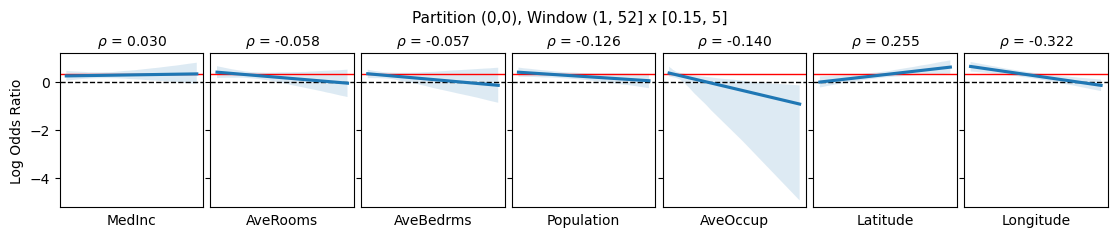

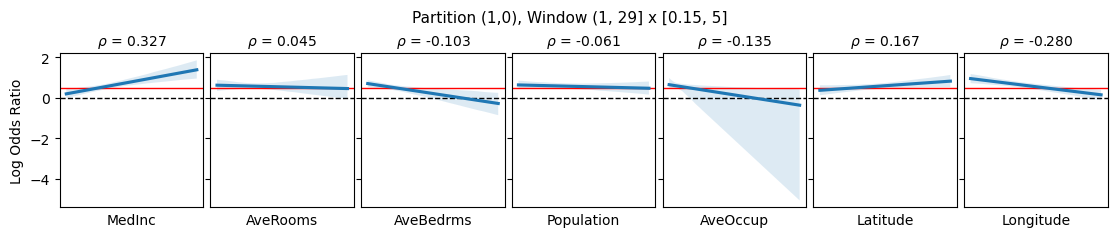

In [5]:
col1, col2 = 'HouseAge', 'MedHouseVal' # conditional independence of HousAge and MedHouseVal given all the other variables
x = california_housing.frame[col1].to_numpy()
y = california_housing.frame[col2].to_numpy()
df = california_housing.frame.drop(columns=[col1, col2])
Z = df.to_numpy()
colnames = df.columns.tolist()

tic = time.process_time()
output = multiCMH(x=x, y=y, Z=Z, alp=0.05, verbose=True)
toc = time.process_time()
print(output)
print(f'CPU time eplased {toc - tic} seconds')

output.print_significant_windows()
output.diagnose_significant_windows(0, colnames=colnames)
output.diagnose_significant_windows(1, colnames=colnames)